In [ ]:
# In the name of GOD, the Most Gracious, the Most Merciful

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

C:\Users\fatem\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\fatem\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


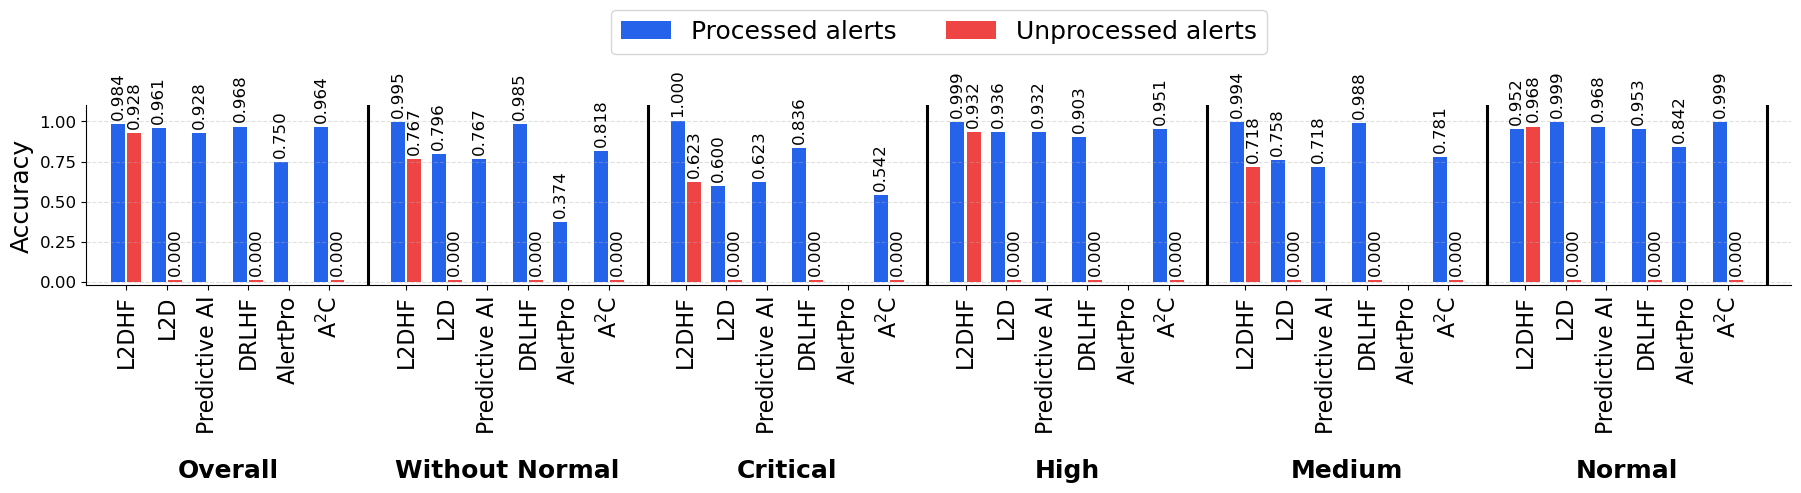

In [2]:
# ==========================
# Data
# ==========================

categories = [
    "Overall",
    "Without Normal",
    "Critical",
    "High",
    "Medium",
    "Normal"
]

models = [
    "L2DHF",
    "L2D",
    "Predictive AI",
    "DRLHF",
    "AlertPro",
    r"A$^2$C"
]

processed = {
    "Overall":        [0.984, 0.961, 0.928, 0.968, 0.750, 0.964],
    "Without Normal": [0.995, 0.796, 0.767, 0.985, 0.374, 0.818],
    "Critical":       [1.000, 0.600, 0.623, 0.836, None, 0.542],
    "High":           [0.999, 0.936, 0.932, 0.903, None, 0.951],
    "Medium":         [0.994, 0.758, 0.718, 0.988, None, 0.781],
    "Normal":         [0.952, 0.999, 0.968, 0.953, 0.842, 0.999]
}

unprocessed = {
    "Overall":        [0.928, 0.0, None, 0.0, None, 0.0],
    "Without Normal": [0.767, 0.0, None, 0.0, None, 0.0],
    "Critical":       [0.623, 0.0, None, 0.0, None, 0.0],
    "High":           [0.932, 0.0, None, 0.0, None, 0.0],
    "Medium":         [0.718, 0.0, None, 0.0, None, 0.0],
    "Normal":         [0.968, 0.0, None, 0.0, None, 0.0]
}

# ==========================
# Plot settings (FIXED)
# ==========================

fig, ax = plt.subplots(figsize=(22, 3))

# bar_width = 1.3         # 🔥 thicker bars (was 0.30)
model_spacing = 4.5      # 🔥 more space between models
group_spacing = 4       # 🔥 more space between categories

xticks = []
xticklabels = []
group_centers = []

current_x = 1

# helper for tiny bars when value is 0.0
def safe_height(v):
    if v == 0.0:
        return 0.014  # tiny visible bar
    return v

# ==========================
# Draw bars
# ==========================

pair_offset = 0.9     # distance from centre
bar_width = 1.3         # thick bars

for category in categories:

    start_group = current_x

    for i, model in enumerate(models):

        proc = processed[category][i]
        unproc = unprocessed[category][i]

        center = current_x

        blue_x = center - pair_offset
        red_x  = center + pair_offset

        if proc is not None:

            h = safe_height(proc)

            ax.bar(
                blue_x,
                h,
                width=bar_width+0.25,
                color='#2563EB',
                align='center',
                label='Processed alerts'
                if (category == categories[0] and i == 0)
                else ""
            )

            ax.text(
                blue_x,
                h + 0.045,
                f"{proc:.3f}",
                ha='center',
                rotation=90,
                fontsize=12
            )

        if unproc is not None:

            h = safe_height(unproc)

            ax.bar(
                red_x,
                h,
                width=bar_width+0.25,
                color='#EF4444',
                align='center',
                label='Unprocessed alerts'
                if (category == categories[0] and i == 0)
                else ""
            )

            ax.text(
                red_x,
                h + 0.045,
                f"{unproc:.3f}",
                ha='center',
                rotation=90,
                fontsize=12
            )

        xticks.append(center)
        xticklabels.append(model)

        current_x += model_spacing
        
    end_group = current_x - model_spacing
    group_centers.append((start_group + end_group) / 2)

    # separator line
    ax.axvline(
        current_x - model_spacing/20,
        color='black',
        linestyle='-',
        alpha=1,
        linewidth = 2.2
    )

    current_x += group_spacing

# ==========================
# X axis (MODEL LABELS)
# ==========================

ax.set_xticks(xticks)
ax.set_xticklabels(
    xticklabels,
    rotation=90,   # 🔥 FIX: no rotation = no overlap
    ha='center',
    fontsize=16
)

# ==========================
# CATEGORY LABELS (CENTERED)
# ==========================

for center, category in zip(group_centers, categories):
    ax.text(
        center,
        -1.1,
        category,
        ha='center',
        va='top',
        fontsize=18,
        fontweight='bold'
    )

# ==========================
# Formatting
# ==========================

ax.set_ylabel("Accuracy", fontsize=18)
ax.set_ylim(-0.02, 1.1)
ax.tick_params(axis='y', labelsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.4)

# 🔥 FIX: legend outside plot (no overlap)
ax.legend(
    fontsize=18,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.6),
    ncol=2
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(bottom=0.20, top=0.80)
ax.margins(x=0.015)
# plt.savefig("Accuracy_all_CICIDS2017.pdf", bbox_inches='tight')
plt.show()

In [4]:
# Effect_size
def Effect_size(x, y):
    # remove None values
    x = [d for d in x if d is not None]
    y = [d for d in y if d is not None]
    
    # convert to nparray 
    x = np.asarray(x)
    y = np.asarray(y)
    
    effect_size = pg.mwu(x=x, y=y, alternative='two-sided')['RBC'].iloc[0]
    
    return effect_size

In [5]:
# Bootstrap CI
def Confidence_Interval(x, y):
    # remove None values
    x = [d for d in x if d is not None]
    y = [d for d in y if d is not None]
    
    # convert to nparray 
    x = np.asarray(x)
    y = np.asarray(y)
    
    ci = pg.compute_bootci(x, y, func=Effect_size, n_boot=2000, seed=42)
    
    return ci



In [6]:
def mwu_stats(x, y):
    
    # remove None values
    x = [d for d in x if d is not None]
    y = [d for d in y if d is not None]
    
    # remove None values
    x = np.asarray(x)
    y = np.asarray(y)


    res = pg.mwu(x=x, y=y, alternative='two-sided')

    return {
        'U_val': res['U_val'].iloc[0],
        'p_val': res['p_val'].iloc[0],
        'RBC': res['RBC'].iloc[0],
        'CLES': res['CLES'].iloc[0]
        
    }

In [ ]:
# Accuracy, P-value, Effect_size and Conficence_Interval

In [ ]:
# Uploading accuracy data

In [ ]:
with open('accuracy_data_L2DHF_CICIDS2017_6PCA.json', 'r') as file:
    accuracy_data_L2DHF_CICIDS2017_6PCA = json.load(file)

In [ ]:
for key in accuracy_data_L2DHF_CICIDS2017_6PCA.keys():
    print(key)

In [ ]:
with open('accuracy_data_DRLHF_CICIDS2017_6PCA.json', 'r') as file:
    accuracy_data_DRLHF_CICIDS2017_6PCA = json.load(file)

In [ ]:
for key in accuracy_data_DRLHF_CICIDS2017_6PCA.keys():
    print(key)

In [ ]:
with open('accuracy_data_L2D_CICIDS2017.json', 'r') as file:
    accuracy_data_L2D_CICIDS2017 = json.load(file)

In [ ]:
for key in accuracy_data_L2D_CICIDS2017.keys():
    print(key)

In [ ]:
with open('accuracy_data_Ensemble_CICIDS2017.json', 'r') as file:
    accuracy_data_Ensemble_CICIDS2017 = json.load(file)

In [ ]:
for key in accuracy_data_Ensemble_CICIDS2017.keys():
    print(key)

In [ ]:
with open('accuracy_data_A2C_TimeModified_CICIDS2017.json', 'r') as file:
    accuracy_data_A2C_TimeModified_CICIDS2017 = json.load(file)

In [ ]:
for key in accuracy_data_A2C_TimeModified_CICIDS2017.keys():
    print(key)

In [ ]:
with open('accuracy_data_AlertPro_CICIDS2017.json', 'r') as file:
    accuracy_data_AlertPro_CICIDS2017 = json.load(file)

In [ ]:
for key in accuracy_data_AlertPro_CICIDS2017.keys():
    print(key)

In [ ]:
# pingouin.mwu(x, y, alternative='two-sided', **kwargs)
# The rank biserial correlation (RBC) ranges from -1 to 1.
# Negative values indicate that y > x.
# Positive values indicate x > y.
# Accuracy is a profit measure. That is, the higher accuracy, the better the performance.
# x: L2DHF
# y: model (baselines, SOTA)

In [ ]:
# Accuracy related calculations
# Calculate P_value, effect_size, confidence intervals of models versus L2DHF
accuracy_results = []

models = {
    "DRLHF": accuracy_data_DRLHF_CICIDS2017_6PCA,
    "L2D": accuracy_data_L2D_CICIDS2017,
    "Ensemble": accuracy_data_Ensemble_CICIDS2017,
    "A2C": accuracy_data_A2C_TimeModified_CICIDS2017,
    "AlertPro": accuracy_data_AlertPro_CICIDS2017
}

categories = [
    "overall",
    "critical",
    "high",
    "medium",
    "low",
    "normal",
    "without_normal"
]

for model_name, model_dict in models.items():

    for category in categories:

        # Find the corresponding L2DHF key
        l2dhf_key = next(
            (
                key
                for key in accuracy_data_L2DHF_CICIDS2017_6PCA.keys()
                if f"accuracy_{category}_" in key
            ),
            None
        )

        # Find the corresponding key in the comparison model
        model_key = next(
            (
                key
                for key in model_dict.keys()
                if f"accuracy_{category}_" in key
            ),
            None
        )

        # Skip categories not available in either dictionary
        if l2dhf_key is None or model_key is None:
            continue

        x = accuracy_data_L2DHF_CICIDS2017_6PCA[l2dhf_key]
        y = model_dict[model_key]

        stats = mwu_stats(x, y)

        P_value = stats['p_val']
        Effect_size_point = stats['RBC']

        CI_value = Confidence_Interval(x, y)

        accuracy_results.append({
            "Model": model_name,
            "Category": category,
            "P_value_accuracy": P_value,
            "Effect_size_accuracy": Effect_size_point,
            "CI_Lower_accuracy": CI_value[0],
            "CI_Upper_accuracy": CI_value[1]
        })

accuracy_results_df = pd.DataFrame(accuracy_results)



In [ ]:
print(accuracy_results_df)

In [ ]:
accuracy_results_df.to_json(
    'accuracy_statistic_results_CICIDS2017.json',
    orient='records',
    indent=4
)

In [ ]:
# Unprocessed alerts, Deferred alerts 

In [ ]:
# Uploading unprocessed alerts

In [7]:
with open('all_Analyst_workload_A2C_CICIDS2017.json', 'r') as file:
    all_Analyst_workload_A2C_CICIDS2017 = json.load(file)

In [8]:
with open('all_Analyst_workload_DRLHF_6PCA_CICIDS2017.json', 'r') as file:
    all_Analyst_workload_DRLHF_6PCA_CICIDS2017 = json.load(file)

In [9]:
with open('all_Analyst_workload_L2D_CICIDS2017.json', 'r') as file:
    all_Analyst_workload_L2D_CICIDS2017 = json.load(file)

In [10]:
with open('all_Analyst_workload_L2DHF_6PCA_CICIDS2017.json', 'r') as file:
    all_Analyst_workload_L2DHF_6PCA_CICIDS2017 = json.load(file)

In [ ]:
# Uploading deferred alerts

In [11]:
with open('deferred_alerts_to_analyst_A2C_CICIDS2017.json', 'r') as file:
    deferred_alerts_to_analyst_A2C_CICIDS2017 = json.load(file)

In [12]:
with open('deferred_alerts_to_analyst_DRLHF_6PCA_CICIDS2017.json', 'r') as file:
    deferred_alerts_to_analyst_DRLHF_6PCA_CICIDS2017 = json.load(file)

In [13]:
with open('deferred_alerts_to_analyst_L2D_CICIDS2017.json', 'r') as file:
    deferred_alerts_to_analyst_L2D_CICIDS2017 = json.load(file)

In [14]:
with open('deferred_alerts_to_analyst_L2DHF_6PCA_CICIDS2017.json', 'r') as file:
    deferred_alerts_to_analyst_L2DHF_6PCA_CICIDS2017 = json.load(file)

In [ ]:
# Uploading remaining time

In [15]:
with open('all_Remaining_time_L2DHF_6PCA_CICIDS2017.json', 'r') as file:
    all_Remaining_time_L2DHF_6PCA_CICIDS2017 = json.load(file)

In [16]:
with open('all_Remaining_time_L2D_CICIDS2017.json', 'r') as file:
    all_Remaining_time_L2D_CICIDS2017 = json.load(file)

In [17]:
with open('all_Remaining_time_DRLHF_6PCA_CICIDS2017.json', 'r') as file:
    all_Remaining_time_DRLHF_6PCA_CICIDS2017 = json.load(file)

In [18]:
with open('all_Remaining_time_A2C_CICIDS2017.json', 'r') as file:
    all_Remaining_time_A2C_CICIDS2017 = json.load(file)

In [20]:
import numpy as np

def split_into_segments(data):
    return [
        data[0:500],
        data[500:1000],
        data[1000:1500],
        data[1500:]
    ]

In [21]:
def plot_segmented_boxplots(ax, datasets, title):

    models = ['L2DHF', 'L2D', 'DRLHF', 'A$^2$C']

    segment_color = 'lightblue'
    overall_color = 'lightcoral'

    positions = []
    all_box_data = []

    current_pos = 1

    for data in datasets:

        segments = split_into_segments(data)

        # four segments + overall
        group_data = segments + [data]

        all_box_data.extend(group_data)

        group_positions = np.arange(current_pos,
                                    current_pos + 5)

        positions.extend(group_positions)

        current_pos += 6     # leave gap between models

    bp = ax.boxplot(
        all_box_data,
        positions=positions,
        widths=0.7,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        meanprops=dict(
            color='black',
            linewidth=2
        ),
        medianprops=dict(
            color='none',
            linewidth=0
    )
    )

    # colour boxes
    for i, box in enumerate(bp['boxes']):

        if (i + 1) % 5 == 0:
            box.set_facecolor(overall_color)
        else:
            box.set_facecolor(segment_color)

    # --------------------------------------------------
    # connect means for first four segments
    # --------------------------------------------------

    current_pos = 1

    for data in datasets:

        segments = split_into_segments(data)

        means = [np.mean(s) for s in segments]

        x = np.arange(current_pos,
                      current_pos + 4)

        ax.plot(
            x,
            means,
            marker='o',
            linewidth=2,
            color='red'
        )

        current_pos += 6

    # --------------------------------------------------
    # x labels
    # --------------------------------------------------

    model_centres = []

    current_pos = 1

    for _ in models:

        model_centres.append(current_pos + 2)

        current_pos += 6

    ax.set_xticks(model_centres)
    ax.set_xticklabels(models, fontsize=16)

    ax.set_title(title, fontsize=18)

    ax.grid(True, alpha=0.3)

    legend_items = [
        Patch(facecolor=segment_color,
              label='Segments'),
        Patch(facecolor=overall_color,
              label='All time steps'),
        Line2D([0], [0],
               color='red',
               marker='o',
               linewidth=2,
               label='Mean trend')
    ]

    ax.legend(handles=legend_items,
              loc='upper right', fontsize=14)

In [22]:
#unprocessed
data1 = all_Analyst_workload_L2DHF_6PCA_CICIDS2017     
data2 = all_Analyst_workload_L2D_CICIDS2017       
data3 = all_Analyst_workload_DRLHF_6PCA_CICIDS2017         
data4 = all_Analyst_workload_A2C_CICIDS2017 

# Deferred
data5 = deferred_alerts_to_analyst_L2DHF_6PCA_CICIDS2017     
data6 = deferred_alerts_to_analyst_L2D_CICIDS2017       
data7 = deferred_alerts_to_analyst_DRLHF_6PCA_CICIDS2017     
data8 = deferred_alerts_to_analyst_A2C_CICIDS2017       


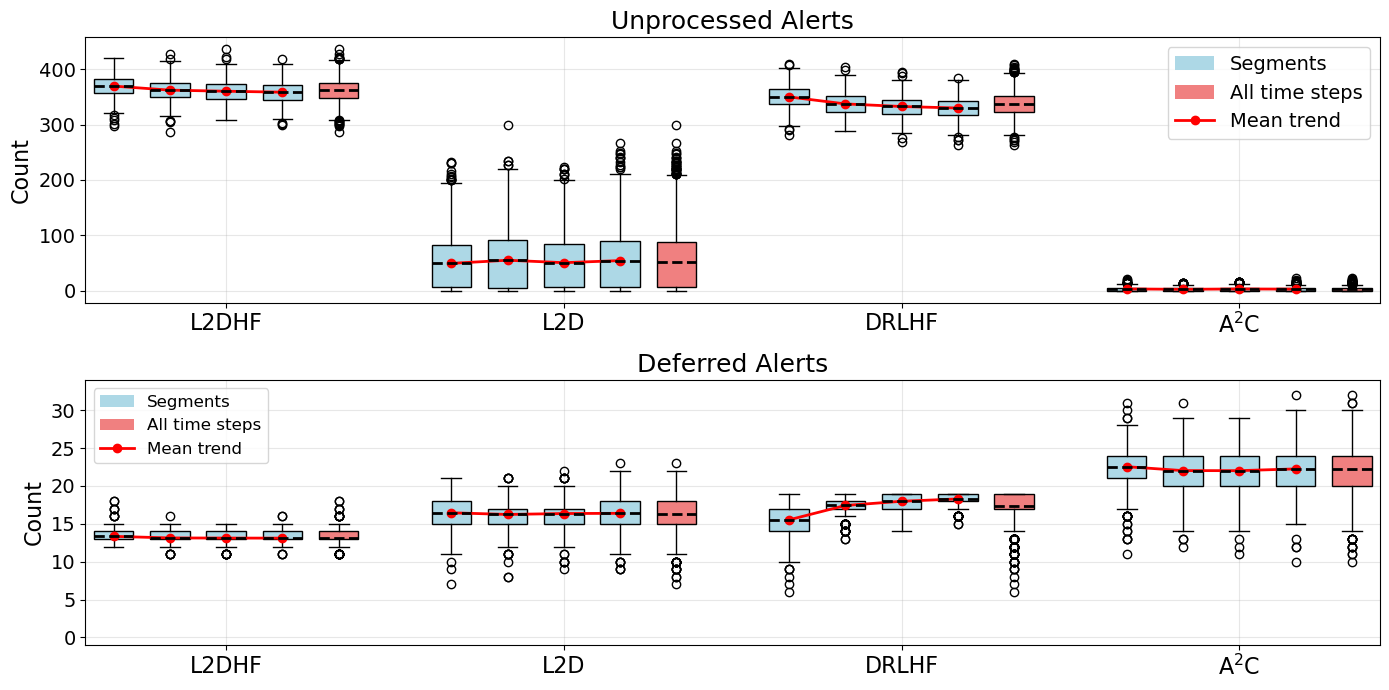

In [23]:
fig2, axs2 = plt.subplots(
    2,
    1,
    figsize=(14,7)
)

plot_segmented_boxplots(
    axs2[0],
    [
        data1,
        data2,
        data3,
        data4
    ],
    'Unprocessed Alerts'
)

plot_segmented_boxplots(
    axs2[1],
    [
        data5,
        data6,
        data7,
        data8
    ],
    'Deferred Alerts'
)

axs2[0].set_ylabel('Count', fontsize=16)
axs2[1].set_ylabel('Count', fontsize=16)

axs2[0].tick_params(axis='y', labelsize=14)
axs2[1].tick_params(axis='y', labelsize=14)

axs2[1].set_ylim(-1, 34)
axs2[1].set_yticks(np.arange(0, 34, 5))

segment_color = 'lightblue'
overall_color = 'lightcoral'

legend_items = [
        Patch(facecolor=segment_color,
              label='Segments'),
        Patch(facecolor=overall_color,
              label='All time steps'),
        Line2D([0], [0],
               color='red',
               marker='o',
               linewidth=2,
               label='Mean trend')
    ]

axs2[1].legend(handles=legend_items, loc='upper left', fontsize=12)

plt.tight_layout()

# plt.savefig("Unprocessed_deferred_alerts_CICIDS2017.pdf", bbox_inches='tight')

plt.show()

In [24]:
#unprocessed
data1 = all_Analyst_workload_L2DHF_6PCA_CICIDS2017     
data2 = all_Analyst_workload_L2D_CICIDS2017       
data3 = all_Analyst_workload_DRLHF_6PCA_CICIDS2017         
data4 = all_Analyst_workload_A2C_CICIDS2017 

# Deferred
data5 = deferred_alerts_to_analyst_L2DHF_6PCA_CICIDS2017     
data6 = deferred_alerts_to_analyst_L2D_CICIDS2017       
data7 = deferred_alerts_to_analyst_DRLHF_6PCA_CICIDS2017     
data8 = deferred_alerts_to_analyst_A2C_CICIDS2017       

# Remaining time

data9 = all_Remaining_time_L2DHF_6PCA_CICIDS2017
data10 = all_Remaining_time_L2D_CICIDS2017
data11 = all_Remaining_time_DRLHF_6PCA_CICIDS2017
data12 = all_Remaining_time_A2C_CICIDS2017

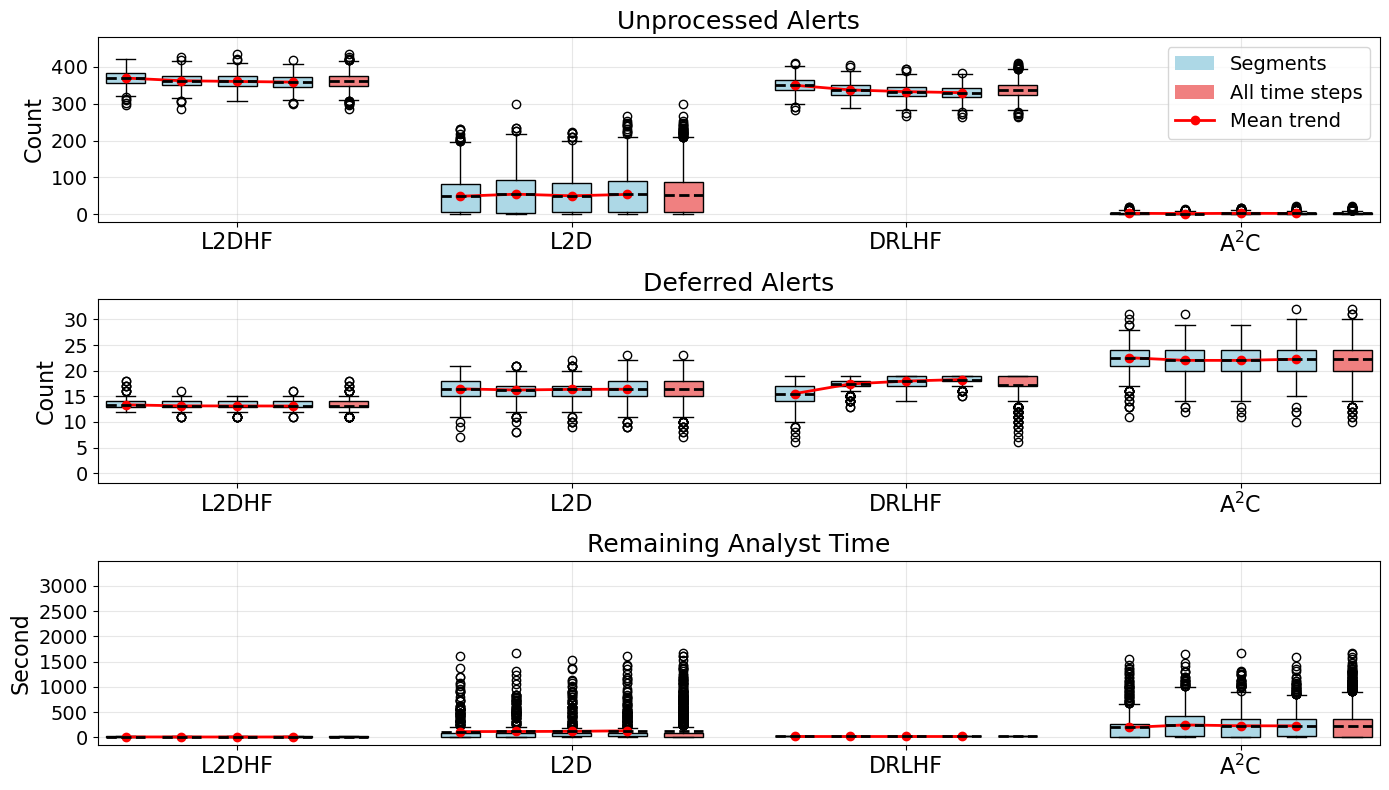

In [25]:
fig2, axs2 = plt.subplots(
    3,
    1,
    figsize=(14,8)
)

plot_segmented_boxplots(
    axs2[0],
    [
        data1,
        data2,
        data3,
        data4
    ],
    'Unprocessed Alerts'
)

plot_segmented_boxplots(
    axs2[1],
    [
        data5,
        data6,
        data7,
        data8
    ],
    'Deferred Alerts'
)

plot_segmented_boxplots(
    axs2[2],
    [
        data9,
        data10,
        data11,
        data12
    ],
    'Remaining Analyst Time'
)

axs2[0].set_ylabel('Count', fontsize=16)
axs2[1].set_ylabel('Count', fontsize=16)
axs2[2].set_ylabel('Second', fontsize=16)

axs2[0].tick_params(axis='y', labelsize=14)
axs2[1].tick_params(axis='y', labelsize=14)
axs2[2].tick_params(axis='y', labelsize=14)

axs2[0].set_ylim(-20, 480)
axs2[0].set_yticks(np.arange(0, 480, 100))

axs2[1].set_ylim(-2, 34)
axs2[1].set_yticks(np.arange(0, 34, 5))

axs2[2].set_ylim(-150, 3500)
axs2[2].set_yticks(np.arange(0, 3500, 500))

segment_color = 'lightblue'
overall_color = 'lightcoral'


axs2[1].get_legend().remove()
axs2[2].get_legend().remove()


plt.tight_layout()
# Save the plot
# plt.savefig("Unprocessed_deferred__remainingTime_alerts_CICIDS2017.pdf", bbox_inches='tight')

plt.show()

In [ ]:
# Unprocessed alerts, Deferred alerts 

In [ ]:
# pingouin.mwu(x, y, alternative='two-sided', **kwargs)
# The rank biserial correlation (RBC) ranges from -1 to 1.
# Negative values indicate that y > x.
# Positive values indicate x > y.
# For 1) unprocessed alert, and 2) deferred alerts as cost metrics (the lower the metric value, the better the performance):
# x: model (baselines, SOTA)
# y: L2DHF

In [ ]:
# P_value, Effect size, CI (uprocessed alerts, deferred alerts)

In [ ]:
#unprocessed

In [ ]:
unprocessed_results = []

In [ ]:
# unprocessed # L2D
x = all_Analyst_workload_L2D_CICIDS2017
y = all_Analyst_workload_L2DHF_6PCA_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

unprocessed_results.append({
    "Model": "L2D",
    "Type": "Unprocessed",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(unprocessed_results[0])


In [ ]:
# unprocessed # DRLHF
x = all_Analyst_workload_DRLHF_6PCA_CICIDS2017
y = all_Analyst_workload_L2DHF_6PCA_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

unprocessed_results.append({
    "Model": "DRLHF",
    "Type": "Unprocessed",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(unprocessed_results[1])

In [ ]:
# unprocessed # A2C
x = all_Analyst_workload_A2C_CICIDS2017
y = all_Analyst_workload_L2DHF_6PCA_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

unprocessed_results.append({
    "Model": "A2C",
    "Type": "Unprocessed",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(unprocessed_results[2])

In [ ]:
# deferred

In [ ]:
deferred_results = []

In [ ]:
# deferred # L2D
x = deferred_alerts_to_analyst_L2D_CICIDS2017
y = deferred_alerts_to_analyst_L2DHF_6PCA_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

deferred_results.append({
    "Model": "L2D",
    "Type": "Deferred",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(deferred_results[0])


In [ ]:
# deferred # DRLHF
x = deferred_alerts_to_analyst_DRLHF_6PCA_CICIDS2017 
y = deferred_alerts_to_analyst_L2DHF_6PCA_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

deferred_results.append({
    "Model": "DRLHF",
    "Type": "Deferred",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(deferred_results[1])

In [ ]:
# deferred # A2C
x = deferred_alerts_to_analyst_A2C_CICIDS2017
y = deferred_alerts_to_analyst_L2DHF_6PCA_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

deferred_results.append({
    "Model": "A2C",
    "Type": "Deferred",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(deferred_results[2])

In [ ]:
# pingouin.mwu(x, y, alternative='two-sided', **kwargs)
# The rank biserial correlation (RBC) ranges from -1 to 1.
# Negative values indicate that y > x.
# Positive values indicate x > y.
# For remaining_analyst_time which is a benefit metric (the higher the metric value, the better the performance):
# x: L2DHF 
# y: model (baselines, SOTA)

In [ ]:
# remaining analyst time

In [26]:
remaining_analyst_time = []

In [27]:
# remaining_analyst_time # L2D
x = all_Remaining_time_L2DHF_6PCA_CICIDS2017 
y = all_Remaining_time_L2D_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

remaining_analyst_time.append({
    "Model": "L2D",
    "Type": "remaining_analyst_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(remaining_analyst_time[0])


{'Model': 'L2D', 'Type': 'remaining_analyst_time', 'P_value': 2.1739006943026143e-235, 'Effect_size': -0.558783698664651, 'CI_Lower': -0.58, 'CI_Upper': -0.53}


In [28]:
# remaining_analyst_time # DRLHF
x = all_Remaining_time_L2DHF_6PCA_CICIDS2017
y = all_Remaining_time_DRLHF_6PCA_CICIDS2017
stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

remaining_analyst_time.append({
    "Model": "DRLHF",
    "Type": "remaining_analyst_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(remaining_analyst_time[1])

{'Model': 'DRLHF', 'Type': 'remaining_analyst_time', 'P_value': 0.0, 'Effect_size': -0.6408730158730158, 'CI_Lower': -0.66, 'CI_Upper': -0.62}


In [29]:
# remaining_analyst_time # A2C
x = all_Remaining_time_L2DHF_6PCA_CICIDS2017
y = all_Remaining_time_A2C_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

remaining_analyst_time.append({
    "Model": "A2C",
    "Type": "remaining_analyst_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(remaining_analyst_time[2])

{'Model': 'A2C', 'Type': 'remaining_analyst_time', 'P_value': 1.0214279200823187e-246, 'Effect_size': -0.5740514377047115, 'CI_Lower': -0.6, 'CI_Upper': -0.55}


In [30]:
data = remaining_analyst_time

with open('remaining_analyst_time_CICIDS2017.json', 'w') as json_file:
    json.dump(data, json_file, indent=4)

In [ ]:
# CICIDS2017

In [ ]:
with open('all_time_step_execution_time_L2DHF_6PCA_CICIDS2017.json', 'r') as file:
    all_time_step_execution_time_L2DHF_6PCA_CICIDS2017 = json.load(file)

In [ ]:
with open('all_time_step_execution_time_L2D_CICIDS2017.json', 'r') as file:
    all_time_step_execution_time_L2D_CICIDS2017 = json.load(file)

In [ ]:
with open('all_time_step_execution_time_DRLHF_6PCA_CICIDS2017.json', 'r') as file:
    all_time_step_execution_time_DRLHF_6PCA_CICIDS2017 = json.load(file)

In [ ]:
with open('all_time_step_execution_time_AlertPro_CICIDS2017.json', 'r') as file:
    all_time_step_execution_time_AlertPro_CICIDS2017 = json.load(file)

In [ ]:
with open('all_time_step_execution_time_A2C_CICIDS2017.json', 'r') as file:
    all_time_step_execution_time_A2C_CICIDS2017 = json.load(file)

In [ ]:
# pingouin.mwu(x, y, alternative='two-sided', **kwargs)
# The rank biserial correlation (RBC) ranges from -1 to 1.
# Negative values indicate that y > x.
# Positive values indicate x > y.
# For Execution time as a cost metric (the lower the metric value, the better the performance):
# x: model (baselines, SOTA)
# y: L2DHF

In [ ]:
execution_time_results = []

In [ ]:
# execution_time # L2D
x = all_time_step_execution_time_L2D_CICIDS2017
y = all_time_step_execution_time_L2DHF_6PCA_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

execution_time_results.append({
    "Model": "L2D",
    "Type": "execution_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(execution_time_results[0])


In [ ]:
# execution_time # DRLHF
x = all_time_step_execution_time_DRLHF_6PCA_CICIDS2017
y = all_time_step_execution_time_L2DHF_6PCA_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

execution_time_results.append({
    "Model": "DRLHF",
    "Type": "execution_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(execution_time_results[1])

In [ ]:
# execution_time # AlertPro
x = all_time_step_execution_time_AlertPro_CICIDS2017
y = all_time_step_execution_time_L2DHF_6PCA_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

execution_time_results.append({
    "Model": "AlertPro",
    "Type": "execution_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(execution_time_results[2])

In [ ]:
# execution_time # A2C
x = all_time_step_execution_time_A2C_CICIDS2017
y = all_time_step_execution_time_L2DHF_6PCA_CICIDS2017

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

execution_time_results.append({
    "Model": "A2C",
    "Type": "execution_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(execution_time_results[3])